### Imports

In [64]:
from pathlib import Path
import numpy as np
from PIL import Image
import time
import pandas as pd
import pyopencl as cl
import matplotlib.pyplot as plt
import cv2

## pd.set_option("display.max_rows", None)

### Config

In [ ]:
# Die getesteten Bildgroessen werden zentral definiert, dadurch laufen alle Varianten auf denselben Eingabedaten
image_paths = [
    Path("images_input/1.nature_small.jpeg"),
    Path("images_input/2.nature_medium.jpeg"),
    Path("images_input/3.nature_large.jpeg"),
    Path("images_input/4.nature_mega.jpeg"),
]

# Parameter für die Anpassung von Kontrast und Helligkeit.
alpha_cpu = 1.3 # Kontrast
beta_cpu = 20 # Helligkeit

# Für den OpenCL-Kernel werden die Parameter explizit als float32 gespeichert, da der OpenCL-Datentyp float ebenfalls 32 Bit verwendet
alpha_pyopencl = np.float32(1.3)
beta_pyopencl = np.float32(20)

# Anzahl der eigentlichen Messläufe pro Bild und Implementierung
# Aus diesen 100 Messwerten wird später der Median berechnet
runs = 100

# Vor den eigentlichen Messungen werden fünf Warm-up Läufe ausgeführt
# Diese werden nicht ausgewertet
warmup_runs = 5

### Baseline Func

In [ ]:
# Verarbeitet ein RGB-Bild mit NumPy auf der CPU

def process_cpu(rgb_matrix):
    # Die drei Farbkanäle werden getrennt aus der RGB Matrix gelesen
    red = rgb_matrix[:, :, 0]
    green = rgb_matrix[:, :, 1]
    blue = rgb_matrix[:, :, 2]

    # Berechnung des Grauwerts nach der vorgegebenen Gewichtung der drei Farbkanäle
    gray_matrix = 0.21 * red + 0.72 * green + 0.07 * blue
    # Umwandlung in uint8, da Bildwerte nur den Bereich 0 bis 255 benötigen
    gray_matrix = gray_matrix.astype(np.uint8)

    # Anpassung von Kontrast und Helligkeit
    gray_matrix_2 = alpha_cpu * gray_matrix + beta_cpu
    # Werte außerhalb des gültigen 8-Bit-Bereichs werden auf 0 beziehungsweise 255 begrenzt
    gray_matrix_2 = np.clip(gray_matrix_2, 0, 255)
    # Das Ergebnis wird wieder als 8-Bit-Bild gespeichert
    gray_matrix_2 = gray_matrix_2.astype(np.uint8)

    # Für das Histogramm wird die zweidimensionale Bildmatrix zunächst in ein eindimensionales Array umgewandelt
    histogram = np.bincount(gray_matrix_2.flatten(), minlength=256)

    return gray_matrix_2, histogram

### PyOpenCL Config

In [ ]:
context = cl.create_some_context()
queue = cl.CommandQueue(context)

# Abkürzung für die OpenCL-Speicherflags
mf = cl.mem_flags

# 1. RGB -> Graustufen + Helligkeits-/Kontrastanpassung
# 2. Berechnung des Histogramms
program = cl.Program(context, """
#pragma OPENCL EXTENSION cl_khr_global_int32_base_atomics : enable
/*
 * Kernel für Graustufenumwandlung sowie
 * Helligkeits- und Kontrastanpassung
 *
 * Jedes Work-Item verarbeitet genau einen Pixel
 */
__kernel void rgb_to_grayscale_brightness_contrast(
    __global const uchar *rgb,
    __global uchar *gray_out,
    const float alpha,
    const float beta
)
{
    int pixel_id = get_global_id(0);
    int rgb_id = pixel_id * 3;

    uchar red = rgb[rgb_id];
    uchar green = rgb[rgb_id + 1];
    uchar blue = rgb[rgb_id + 2];

    uchar gray_value = (uchar)(0.21f * red + 0.72f * green + 0.07f * blue);
    float value = alpha * gray_value + beta;

    if (value < 0.0f) {
        value = 0.0f;
    }

    if (value > 255.0f) {
        value = 255.0f;
    }

    gray_out[pixel_id] = (uchar)(value);
}
/*
 * Kernel zur Berechnung des Histogramms
 *
 * Jedes Work-Item verarbeitet einen Grauwert und erhöht
 * den entsprechenden Eintrag im Histogramm
 */
__kernel void compute_histogram(
    __global const uchar *gray,
    __global int *histogram
)
{
    int pixel_id = get_global_id(0);
    uchar value = gray[pixel_id];
    atomic_inc(&histogram[value]);
}
""").build()

### PyOpenCL Func

In [ ]:
# Verarbeitet ein RGB-Bild parallel mit PyOpenCL
# Die Graustufenumwandlung, Helligkeits-/Kontrastanpassung und Histogrammberechnung werden auf dem OpenCL-Gerät ausgeführt
def process_pyopencl(rgb_matrix):
    # Höhe, Breite und Anzahl der Farbkanäle des Eingabebildes bestimmen
    height, width, channels = rgb_matrix.shape
    # Gesamtanzahl der Pixel
    pixel_count = height * width

    # Die dreidimensionale RGB-Matrix wird in ein eindimensionales Array umgewandelt
    rgb_flat = rgb_matrix.flatten()
    # Speicher für das Ergebnis der GPU-Verarbeitung reservieren
    # Nach der Verarbeitung besitzt jeder Pixel nur noch einen Grauwert
    gray_matrix_flat = np.empty(pixel_count, dtype=np.uint8)
    # Jeder Eintrag entspricht einem Grauwert von 0 bis 255
    histogram = np.zeros(256, dtype=np.int32)

    # Eingabe-Buffer erstellen und die RGB-Daten vom Arbeitsspeicher auf das OpenCL-Gerät übertragen
    rgb_input_buffer = cl.Buffer(context, mf.READ_ONLY | mf.COPY_HOST_PTR, hostbuf=rgb_flat)
    # Ausgabe-Buffer für das verarbeitete Graustufenbild reservieren
    gray_output_buffer = cl.Buffer(context, mf.WRITE_ONLY, gray_matrix_flat.nbytes)
    # Buffer für das Histogramm erstellen und mit den zuvor initialisierten Nullen befüllen
    histogram_buffer = cl.Buffer(context, mf.READ_WRITE | mf.COPY_HOST_PTR, hostbuf=histogram)

    # Ersten Kernel ausführen
    program.rgb_to_grayscale_brightness_contrast(
        queue,
        (pixel_count,),
        None,
        rgb_input_buffer,
        gray_output_buffer,
        alpha_pyopencl,
        beta_pyopencl
    )

    # Histogramm direkt aus dem Ergebnis des ersten Kernels berechnen
    program.compute_histogram(
        queue,
        (pixel_count,),
        None,
        gray_output_buffer,
        histogram_buffer
    )

    # Das fertig verarbeitete Graustufenbild vom OpenCL-Gerät zurück in den Arbeitsspeicher kopieren
    cl.enqueue_copy(queue, gray_matrix_flat, gray_output_buffer)
    # Histogramm ebenfalls zurück in den Arbeitsspeicher übertragen
    cl.enqueue_copy(queue, histogram, histogram_buffer)
    queue.finish()

    return gray_matrix_flat, histogram

### OpenCV Func

In [ ]:
# Verarbeitet das Bild mit den optimierten OpenCV-Funktionen
def process_opencv(rgb_matrix):
    # Konvertierung des RGB-Bildes in ein Graustufenbild
    # OpenCV verwendet dafür seine eigene optimierte Standardgewichtung der Farbkanäle
    gray_matrix = cv2.cvtColor(rgb_matrix, cv2.COLOR_RGB2GRAY)

    # Helligkeit und Kontrast anpassen
    gray_matrix_2 = cv2.convertScaleAbs(
        gray_matrix,
        alpha=alpha_cpu,
        beta=beta_cpu
    )

    # Histogramm für alle 256 möglichen Grauwerte berechnen
    histogram = cv2.calcHist([gray_matrix_2], [0], None, [256], [0, 256])
    # OpenCV liefert das Histogramm als Matrix mit der Form (256, 1) 
    histogram = histogram.flatten()

    return gray_matrix_2, histogram

### Benchmark Baseline

In [ ]:
# Liste zur Speicherung aller einzelnen Laufzeitmessungen der CPU-Baseline
cpu_results = []

# Alle vier Bildgrößen nacheinander testen
for image_path in image_paths:
    # Bild außerhalb der eigentlichen Zeitmessung laden
    image = Image.open(image_path)
    rgb_matrix = np.array(image, dtype=np.uint8)

    # Bildinformationen für die spätere Auswertung bestimmen
    height, width, channels = rgb_matrix.shape
    pixel_count = height * width

    # Warm-up-Läufe werden vor der eigentlichen Messung ausgeführt
    for _ in range(warmup_runs): # Warm-up
       process_cpu(rgb_matrix)  

    # Für jedes Bild werden 100 Laufzeitmessungen durchgeführt
    for run in range(1, runs + 1):
        start = time.perf_counter()

        # Durchführung aller drei Verarbeitungsschritte:
        # Graustufen, Helligkeit/Kontrast und Histogramm
        cpu_image, cpu_histogram = process_cpu(rgb_matrix)

        end = time.perf_counter()

        # Messwert zusammen mit den Bildinformationen speichern
        cpu_results.append({
            "image": image_path.name,
            "width": width,
            "height": height,
            "pixel_count": pixel_count,
            "run": run,
            "cpu_time_s": end - start
        })

# Alle Einzelmessungen in einem Pandas-DataFrame speichern.
# Dadurch können die Werte anschließend gruppiert und statistisch ausgewertet werden
cpu_raw_df = pd.DataFrame(cpu_results)
cpu_raw_df

,image,width,height,pixel_count,run,cpu_time_s
0,1.nature_small.jpeg,640,415,265600,1,0.001702
1,1.nature_small.jpeg,640,415,265600,2,0.002190
2,1.nature_small.jpeg,640,415,265600,3,0.001804
3,1.nature_small.jpeg,640,415,265600,4,0.001565
4,1.nature_small.jpeg,640,415,265600,5,0.001528
...,...,...,...,...,...,...
395,4.nature_mega.jpeg,2048,1327,2717696,96,0.149316
396,4.nature_mega.jpeg,2048,1327,2717696,97,0.150741
397,4.nature_mega.jpeg,2048,1327,2717696,98,0.162975
398,4.nature_mega.jpeg,2048,1327,2717696,99,0.152306


### Benchmark PyOpenCl

In [ ]:
# Liste für alle einzelnen PyOpenCL-Laufzeitmessungen
pyopencl_results = []

for image_path in image_paths:
    # Eingabebild laden und in eine uint8-RGB-Matrix umwandeln
    image = Image.open(image_path)
    rgb_matrix = np.array(image, dtype=np.uint8)

    # Bildgröße und Pixelanzahl für die spätere Auswertung speichern
    height, width, channels = rgb_matrix.shape
    pixel_count = height * width

    # Warm-up-Läufe durchführen
    for _ in range(warmup_runs): # Warm-up
        process_pyopencl(rgb_matrix)

    # 100 Messläufe pro Bildgröße durchführen
    for run in range(1, runs + 1):
        start = time.perf_counter()

        # PyOpenCL-Bildverarbeitung inklusive Kernel-Ausführung, Histogrammberechnung und Rückübertragung der Ergebnisse
        pyopencl_image, pyopencl_histogram = process_pyopencl(rgb_matrix)

        end = time.perf_counter()

        # Einzelmessung mit Bildgröße und Laufnummer speichern
        pyopencl_results.append({
            "image": image_path.name,
            "width": width,
            "height": height,
            "pixel_count": pixel_count,
            "run": run,
            "pyopencl_time_s": end - start
        })

# Einzelmessungen als DataFrame speichern
pyopencl_raw_df = pd.DataFrame(pyopencl_results)
pyopencl_raw_df

C:\Users\maxim\AppData\Local\Temp\ipykernel_37672\1393363500.py:13: RepeatedKernelRetrieval: Kernel 'rgb_to_grayscale_brightness_contrast' has been retrieved more than once. Each retrieval creates a new, independent kernel, at possibly considerable expense. To avoid the expense, reuse the retrieved kernel instance. To avoid this warning, use cl.Kernel(prg, name).
  program.rgb_to_grayscale_brightness_contrast(
C:\Users\maxim\AppData\Local\Temp\ipykernel_37672\1393363500.py:23: RepeatedKernelRetrieval: Kernel 'compute_histogram' has been retrieved more than once. Each retrieval creates a new, independent kernel, at possibly considerable expense. To avoid the expense, reuse the retrieved kernel instance. To avoid this warning, use cl.Kernel(prg, name).
  program.compute_histogram(


,image,width,height,pixel_count,run,pyopencl_time_s
0,1.nature_small.jpeg,640,415,265600,1,0.004314
1,1.nature_small.jpeg,640,415,265600,2,0.003853
2,1.nature_small.jpeg,640,415,265600,3,0.007436
3,1.nature_small.jpeg,640,415,265600,4,0.003820
4,1.nature_small.jpeg,640,415,265600,5,0.004128
...,...,...,...,...,...,...
395,4.nature_mega.jpeg,2048,1327,2717696,96,0.022201
396,4.nature_mega.jpeg,2048,1327,2717696,97,0.024773
397,4.nature_mega.jpeg,2048,1327,2717696,98,0.023229
398,4.nature_mega.jpeg,2048,1327,2717696,99,0.026566


### Benchmark OpenCV

In [ ]:
# Liste für alle einzelnen OpenCV-Laufzeitmessungen.
opencv_results = []

for image_path in image_paths:
    # Eingabebild laden und in eine uint8-RGB-Matrix umwandeln
    image = Image.open(image_path)
    rgb_matrix = np.array(image, dtype=np.uint8)

    # Bildgröße und Pixelanzahl für die spätere Auswertung speichern
    height, width, channels = rgb_matrix.shape
    pixel_count = height * width

    # Warm-up-Läufe durchführen
    for _ in range(warmup_runs): # Warm-up
        process_opencv(rgb_matrix)

    # 100 Messläufe pro Bildgröße durchführen
    for run in range(1, runs + 1):
        start = time.perf_counter()

        # OpenCV-Bildverarbeitung vollständig ausführen
        opencv_image, opencv_histogram = process_opencv(rgb_matrix)

        end = time.perf_counter()

        # Laufzeit und zugehörige Bildinformationen speichern
        opencv_results.append({
            "image": image_path.name,
            "width": width,
            "height": height,
            "pixel_count": pixel_count,
            "run": run,
            "opencv_time_s": end - start
        })

# Einzelmessungen in einen DataFrame übertragen
opencv_raw_df = pd.DataFrame(opencv_results)
opencv_raw_df

,image,width,height,pixel_count,run,opencv_time_s
0,1.nature_small.jpeg,640,415,265600,1,0.000292
1,1.nature_small.jpeg,640,415,265600,2,0.000567
2,1.nature_small.jpeg,640,415,265600,3,0.000359
3,1.nature_small.jpeg,640,415,265600,4,0.000402
4,1.nature_small.jpeg,640,415,265600,5,0.000452
...,...,...,...,...,...,...
395,4.nature_mega.jpeg,2048,1327,2717696,96,0.001053
396,4.nature_mega.jpeg,2048,1327,2717696,97,0.001087
397,4.nature_mega.jpeg,2048,1327,2717696,98,0.001040
398,4.nature_mega.jpeg,2048,1327,2717696,99,0.000995


### Tabelle Median und Speedup

In [ ]:
# Für jede Bildgröße wird der Median der 100 Baseline-Messungen berechnet.
# Der Median ist gegenüber einzelnen Laufzeitausreißern robuster als beispielsweise der arithmetische Mittelwert

cpu_median_df = (
    cpu_raw_df
    .groupby(["image", "width", "height", "pixel_count"], as_index=False)
    ["cpu_time_s"]
    .median()
)

# Median der 100 PyOpenCL-Messungen pro Bildgröße
pyopencl_median_df = (
    pyopencl_raw_df
    .groupby(["image", "width", "height", "pixel_count"], as_index=False)
    ["pyopencl_time_s"]
    .median()
)

# Median der 100 OpenCV-Messungen pro Bildgröße
opencv_median_df = (
    opencv_raw_df
    .groupby(["image", "width", "height", "pixel_count"], as_index=False)
    ["opencv_time_s"]
    .median()
)

# Baseline- und PyOpenCL-Ergebnisse anhand der gemeinsamen Bildinformationen in einer Tabelle zusammenführen
summary_df = cpu_median_df.merge(
    pyopencl_median_df,
    on=["image", "width", "height", "pixel_count"]
)

# OpenCV-Ergebnisse ebenfalls zur gemeinsamen Ergebnistabelle hinzufügen
summary_df = summary_df.merge(
    opencv_median_df,
    on=["image", "width", "height", "pixel_count"]
)

# Speedup von PyOpenCL gegenüber der Baseline berechnen
summary_df["speedup_pyopencl"] = summary_df["cpu_time_s"] / summary_df["pyopencl_time_s"]
# Speedup von OpenCV gegenüber der Baseline berechnen
summary_df["speedup_opencv"] = summary_df["cpu_time_s"] / summary_df["opencv_time_s"]
# Ergebnisse nach steigender Pixelanzahl sortieren, damit die Diagramme von der kleinsten zur größten Bildgröße verlaufen
summary_df = summary_df.sort_values("pixel_count")

summary_df

,image,width,height,pixel_count,cpu_time_s,pyopencl_time_s,opencv_time_s,speedup_pyopencl,speedup_opencv
0,1.nature_small.jpeg,640,415,265600,0.001549,0.003929,0.000269,0.394116,5.758647
1,2.nature_medium.jpeg,1024,663,678912,0.004687,0.009142,0.000599,0.512666,7.820137
2,3.nature_large.jpeg,1280,829,1061120,0.034549,0.013296,0.001045,2.598381,33.046631
3,4.nature_mega.jpeg,2048,1327,2717696,0.101295,0.026052,0.001093,3.888150,92.646499


### Plot 1: Laufzeitvergleich

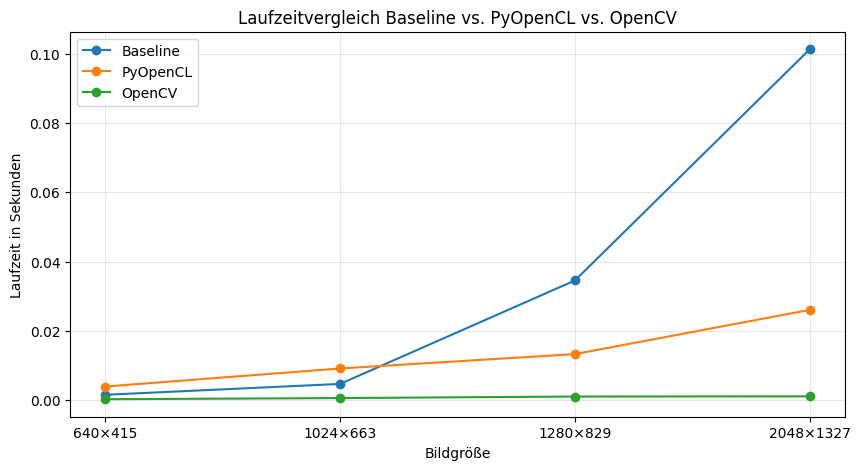

In [ ]:
# Beschriftungen der x-Achse aus Breite und Höhe erzeugen, beispielsweise 640×415
x_labels = summary_df["width"].astype(str) + "×" + summary_df["height"].astype(str)

plt.figure(figsize=(10, 5))
# Median-Laufzeiten der drei Implementierungen darstellen
plt.plot(x_labels, summary_df["cpu_time_s"], marker="o", label="Baseline")
plt.plot(x_labels, summary_df["pyopencl_time_s"], marker="o", label="PyOpenCL")
plt.plot(x_labels, summary_df["opencv_time_s"], marker="o", label="OpenCV")

plt.xlabel("Bildgröße")
plt.ylabel("Laufzeit in Sekunden")
plt.title("Laufzeitvergleich Baseline vs. PyOpenCL vs. OpenCV")
# Gitternetz erleichtert das Ablesen der einzelnen Messwerte
plt.grid(alpha=0.3)
plt.legend()
plt.show()

### Plot 2: Speedup

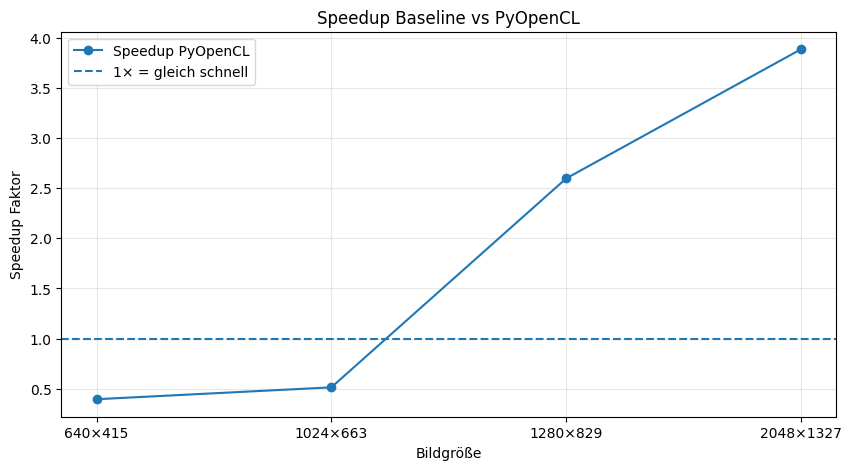

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(x_labels, summary_df["speedup_pyopencl"], marker="o", label="Speedup PyOpenCL")

# Referenzlinie bei Speedup = 1
plt.axhline(1.0, linestyle="--", label="1× = gleich schnell")
plt.xlabel("Bildgröße")
plt.ylabel("Speedup Faktor")
plt.title("Speedup Baseline vs PyOpenCL")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

### Plot 3: Speedup

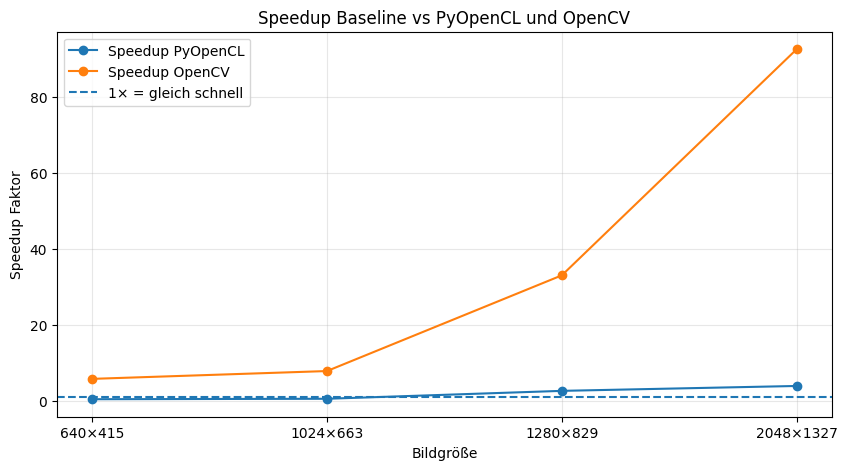

In [76]:
plt.figure(figsize=(10, 5))
plt.plot(x_labels, summary_df["speedup_pyopencl"], marker="o", label="Speedup PyOpenCL")
plt.plot(x_labels, summary_df["speedup_opencv"], marker="o", label="Speedup OpenCV")

plt.axhline(1.0, linestyle="--", label="1× = gleich schnell")
plt.xlabel("Bildgröße")
plt.ylabel("Speedup Faktor")
plt.title("Speedup Baseline vs PyOpenCL und OpenCV")
plt.grid(alpha=0.3)
plt.legend()
plt.show()